# Verification: Ste5–Fus3–Ptc1 switch (Malleshaiah et al., 2010)

This notebook verifies the curated BNGL encodings at two levels. First, it compares
BioNetGen's generated-network ODE results with a separate SciPy implementation of the
33 supplementary equations plus the five active-Fus3 equations. Second, it compares
both published-unit readings with the two curves digitized from Fig. 3b.

The supplement supplies equations and Table 3, but no original Facile or MATLAB file.
Table 3 labels the bimolecular association constants as `/nM/s`; the alternative files
bracket the plausible `/M/s` reading. No fitted value is changed in either reading.

One displayed equation gives the Fus3_Ste5n_2 loss as `-k(P)`. The curated rules use
`k(K)` because both matching gain terms and the Fig. 23b arrow use `k(K)`; using
different loss and gain rates would also violate conservation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "ste5_fus3_ptc1_switch_malleshaiah2010":
    HERE = HERE / "models/ste5_fus3_ptc1_switch_malleshaiah2010"
sys.path.insert(0, str(HERE))

from independent_malleshaiah2010 import simulate

REFERENCE = HERE / "reference"
BASE = "ste5_fus3_ptc1_switch_malleshaiah2010"
VARIANTS = {
    "literal 4PS": (BASE, 4, False),
    "literal 1PS": (BASE + "_1ps", 1, False),
    "molar 4PS": (BASE + "_molar_association_units", 4, True),
    "molar 1PS": (BASE + "_molar_association_units_1ps", 1, True),
}
print("Verification directory:", HERE)

Verification directory: /Users/wish/Code/BNGL-Models/models/ste5_fus3_ptc1_switch_malleshaiah2010


## 1. Model-specification check

`independent_malleshaiah2010.py` codes the fluxes directly from the supplementary
equations; it does not read or integrate the BNG-generated `.net` files. Its state
layout contains free Ste5 states, the three Fus3–Ste5 forms, the three Ptc1–Ste5
forms, active-Fus3 complexes, and free enzymes (38 variables for 4PS; 14 for 1PS).
The comparison tolerance is $5\times10^{-6}$ phosphorylation sites, well above
the numerical integration error but far below the plotted-line uncertainty.

In [2]:
results = {}
rows = []
for label, (stem, n_sites, molar_units) in VARIANTS.items():
    scan_path = REFERENCE / stem / f"{stem}_scan.scan"
    bng = np.genfromtxt(scan_path, names=True)
    independent = []
    conservation = []
    for alpha in bng["alpha"]:
        mean, error = simulate(float(alpha), n_sites, molar_units)
        independent.append(mean)
        conservation.append(error)
    independent = np.asarray(independent)
    results[label] = {
        "alpha_nM": bng["alpha"],
        "bng": bng["Mean_pSites"],
        "independent": independent,
    }
    rows.append({
        "variant": label,
        "species": 38 if n_sites == 4 else 14,
        "reactions": 80 if n_sites == 4 else 23,
        "max |BNG-SciPy|": np.max(np.abs(bng["Mean_pSites"] - independent)),
        "max conservation error (nM)": np.max(conservation),
    })

specification = pd.DataFrame(rows).set_index("variant")
display(specification)
assert (specification["max |BNG-SciPy|"] < 5e-6).all()
assert (specification["max conservation error (nM)"] < 1e-7).all()
print("PASS: all four BNG scans agree with the independent equations.")

,species,reactions,max |BNG-SciPy|,max conservation error (nM)
variant,,,,
literal 4PS,38,80,5.957500e-09,2.418460e-09
literal 1PS,14,23,9.683733e-10,1.757877e-08
molar 4PS,38,80,2.193483e-07,1.989520e-12
molar 1PS,14,23,8.010098e-09,2.955858e-12


PASS: all four BNG scans agree with the independent equations.


## 2. Reported-data check

The red 4PS and 1PS curves were digitized from Fig. 3b on page 3 of the supplied main
paper. `digitize_malleshaiah2010.py` renders the PDF at 300 dpi, crops pixels
`(1360, 1770, 2010, 2290)`, thresholds the red curves, and calibrates the plot using
`x=101..626` for $10^{-3}..10^1$ µM (log scale) and `y=428..92` for 0..4 sites.
The script omits the overlaid legend and open-marker gaps and interpolates through
them. The plotted line is about eight pixels thick, or 0.095 phosphorylation sites;
allowing for the legend reconstruction, 0.15 site is a conservative RMSE tolerance.

In [3]:
reported = {
    "4PS": np.genfromtxt(
        REFERENCE / "malleshaiah2010_fig3b_4ps_digitized.csv",
        delimiter=",", names=True,
    ),
    "1PS": np.genfromtxt(
        REFERENCE / "malleshaiah2010_fig3b_1ps_digitized.csv",
        delimiter=",", names=True,
    ),
}

comparison_rows = []
for reading in ("literal", "molar"):
    for sites in ("4PS", "1PS"):
        label = f"{reading} {sites}"
        model = results[label]
        data = reported[sites]
        prediction = np.interp(
            np.log10(data["alpha_factor_uM"]),
            np.log10(model["alpha_nM"] / 1000.0),
            model["bng"],
        )
        residual = prediction - data["mean_ste5_phosphorylation"]
        comparison_rows.append({
            "variant": label,
            "RMSE (sites)": np.sqrt(np.mean(residual**2)),
            "max abs error (sites)": np.max(np.abs(residual)),
            "model at 10 uM": model["bng"][-1],
            "digitized at 10 uM": data["mean_ste5_phosphorylation"][-1],
        })
        results[label]["reported_prediction"] = prediction
        results[label]["reported_residual"] = residual

reported_metrics = pd.DataFrame(comparison_rows).set_index("variant")
display(reported_metrics)
print("Reported-data tolerance: RMSE <= 0.15 site")
for label, row in reported_metrics.iterrows():
    print(f"{label:12s}: {'PASS' if row['RMSE (sites)'] <= 0.15 else 'NOT REPRODUCED'}")

,RMSE (sites),max abs error (sites),model at 10 uM,digitized at 10 uM
variant,,,,
literal 4PS,2.020134,3.490568,2.989220,0.244048
literal 1PS,0.410197,0.642004,0.694083,0.154762
molar 4PS,0.290120,0.774411,0.481828,0.244048
molar 1PS,0.088805,0.198358,0.227723,0.154762


Reported-data tolerance: RMSE <= 0.15 site
literal 4PS : NOT REPRODUCED
literal 1PS : NOT REPRODUCED
molar 4PS   : NOT REPRODUCED
molar 1PS   : PASS


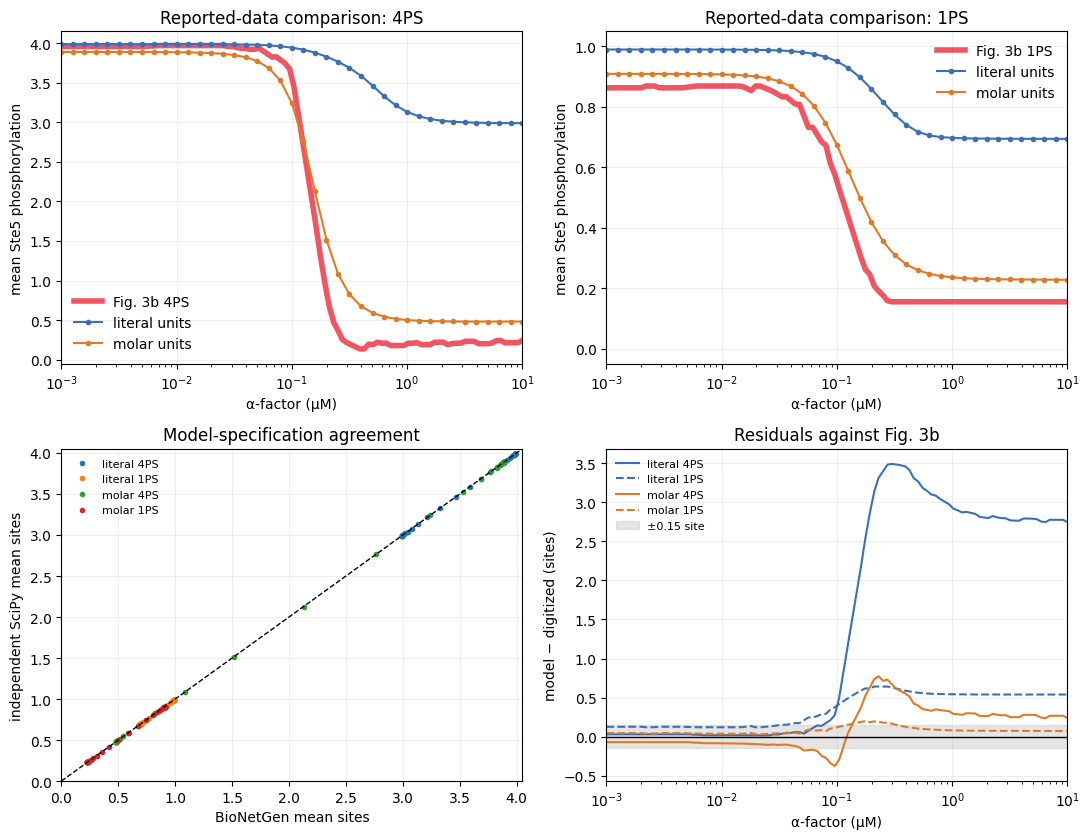

Saved verify_malleshaiah2010.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
colors = {"literal": "#3b6fb6", "molar": "#e07a24"}

for ax, sites in zip(axes[0], ("4PS", "1PS"), strict=True):
    data = reported[sites]
    ax.plot(
        data["alpha_factor_uM"], data["mean_ste5_phosphorylation"],
        color="#ed1c2e", lw=4, alpha=0.75, label=f"Fig. 3b {sites}",
    )
    for reading in ("literal", "molar"):
        model = results[f"{reading} {sites}"]
        ax.plot(model["alpha_nM"] / 1000.0, model["bng"], "o-", ms=3,
                color=colors[reading], label=f"{reading} units")
    ax.set_xscale("log")
    ax.set_xlim(1e-3, 1e1)
    ax.set_ylim(-0.05, 4.15 if sites == "4PS" else 1.05)
    ax.set_xlabel("α-factor (µM)")
    ax.set_ylabel("mean Ste5 phosphorylation")
    ax.set_title(f"Reported-data comparison: {sites}")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

ax = axes[1, 0]
for label, model in results.items():
    ax.plot(model["bng"], model["independent"], "o", ms=3, label=label)
limit = 4.05
ax.plot([0, limit], [0, limit], "k--", lw=1)
ax.set(xlabel="BioNetGen mean sites", ylabel="independent SciPy mean sites",
       title="Model-specification agreement", xlim=(0, limit), ylim=(0, limit))
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)

ax = axes[1, 1]
for label, model in results.items():
    sites = label.split()[1]
    data = reported[sites]
    ax.plot(data["alpha_factor_uM"], model["reported_residual"],
            color=colors[label.split()[0]], ls="-" if sites == "4PS" else "--",
            label=label)
ax.axhspan(-0.15, 0.15, color="0.8", alpha=0.5, label="±0.15 site")
ax.axhline(0, color="k", lw=1)
ax.set_xscale("log")
ax.set(xlabel="α-factor (µM)", ylabel="model − digitized (sites)",
       title="Residuals against Fig. 3b", xlim=(1e-3, 1e1))
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)

fig.tight_layout()
figure_path = HERE / "verify_malleshaiah2010.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved", figure_path.name)

## Conclusion

The BNGL implementation is verified: all four scans agree with the independently
coded supplementary equations and conserve Ste5 and each enzyme pool. The literal
`/nM/s` reading reproduces neither Fig. 3b curve. The `/M/s` reading reproduces the
1PS curve (RMSE below 0.15 site) and is substantially closer for 4PS, but its 4PS curve
still exceeds the digitization tolerance. The literal reading remains primary because
it preserves Table 3 exactly; the `/M/s` files bracket the natural alternative reading.
No fitted parameter was refitted. The one corrected rate symbol is documented above.